<a href="https://colab.research.google.com/github/MarkDeng86/VolatilityPredictionDeepLearning/blob/main/OptiverRV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title
# importing kaggle competition dataset
# make sure to upload kaggle.json to google drive
competition_name = "optiver-realized-volatility-prediction"

# Mount your Google Drive.
from google.colab import drive
drive.mount("/content/drive")

kaggle_creds_path = "/content/drive/MyDrive/kaggle.json"

! pip install kaggle --quiet
! cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
! mkdir ~/.kaggle

! kaggle competitions download -c {competition_name}

! mkdir kaggle_data
! unzip {competition_name + ".zip"} -d kaggle_data

# Unmount your Google Drive
drive.flush_and_unmount()

### IGNORE THIS CELL

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(2026)
DATA_DIR = '/content/drive/MyDrive/TimeSeriesDeepLearning_FIM601/kaggle_data/optiver-realized-volatility-prediction'

### Mark: Below I am testing implementation with polars for more efficient data manipulation. We can translate pandas manipulation to polars pretty easily.

In [ ]:
import polars as pl

In [ ]:
pl_lazy_book_train = pl.scan_parquet(f'{DATA_DIR}/book_train.parquet', hive_partitioning=True)

In [ ]:
# checking book data schema
check_pl = pl.read_parquet_schema(f'{DATA_DIR}/book_train.parquet/stock_id=0/c439ef22282f412ba39e9137a3fdabac.parquet')
print(check_pl)

{'time_id': Int16, 'seconds_in_bucket': Int16, 'bid_price1': Float32, 'ask_price1': Float32, 'bid_price2': Float32, 'ask_price2': Float32, 'bid_size1': Int32, 'ask_size1': Int32, 'bid_size2': Int32, 'ask_size2': Int32}


In [ ]:
# TRANSFORM: Define your preprocessing steps
# Polars builds an optimized query plan for these operations
processed_book = (
    pl_lazy_book_train
    .sort(["stock_id", "time_id", "seconds_in_bucket"])

    # Cast stock_id to int8
    .with_columns(
        pl.col("stock_id").cast(pl.Int8),

        # Calculate the primary WAP (Weighted Average Price)
        wap1 = (pl.col("bid_price1") * pl.col("ask_size1") +
                pl.col("ask_price1") * pl.col("bid_size1")) /
                (pl.col("bid_size1") + pl.col("ask_size1")),
        wap2 = (pl.col("bid_price2") * pl.col("ask_size2") +
                pl.col("ask_price2") * pl.col("bid_size2")) /
                (pl.col("bid_size2") + pl.col("ask_size2")),
        # Calculate the level 1 Bid-Ask spread
        spread1 = pl.col("ask_price1") - pl.col("bid_price1"),
        # Calculate the level 1 and level 1&2 volume
        vol_l1 = pl.col("bid_size1") + pl.col("ask_size1"),
        vol_l2 = pl.col("bid_size2") + pl.col("ask_size2")
    )
    .with_columns(
        # Calculate the total volume
        vol_total = pl.col("vol_l1") + pl.col("vol_l2"),
        # Calculate the volume imbalance
        vol_imbalance = (pl.col("bid_size1") - pl.col("ask_size1")) /
                        (pl.col("bid_size1") + pl.col("ask_size1")),
        wap_basis = (pl.col("wap1") - pl.col("wap2"))
    )


    # Time-Based Features

    .with_columns(
    # Create 60-second micro-buckets (values 0 through 9)
    # This helps models capture structural behaviors, like end-of-bucket trading spikes
    minute_in_bucket = (pl.col("seconds_in_bucket") // 60).cast(pl.Int8),

    # Calculate the time elapsed since the last order book update
    # We fill the first null value in each bucket with 0
    time_since_last_update = (
        pl.col("seconds_in_bucket")
        - pl.col("seconds_in_bucket").shift(1)
    ).over(["stock_id", "time_id"]).fill_null(0)
    )

    # Lagged Variables
    .with_columns(
      # Calculate the tick-to-tick Log Return of the Weighted Average Price
      log_return_1t = (
          pl.col("wap1").log() - pl.col("wap1").shift(1).log()
      ).over(["stock_id", "time_id"]),

      # Calculate how much the spread widened or narrowed since the last update
      spread_change = (
          pl.col("spread1") - pl.col("spread1").shift(1)
      ).over(["stock_id", "time_id"])
    ).fill_null(0) # The first return in a bucket is 0
    .with_columns(
        # Calculate squared returns
        log_return_sq=pl.col("log_return_1t") ** 2
    )
    .with_columns(
        # Calculate expanding realized volatility
        realized_volatility=pl.col("log_return_sq").sum().sqrt().over(["stock_id", "time_id"])
    )


    # # Rolling window statistics
    # .with_columns(
    # # 10-tick rolling mean of the bid-ask spread
    # spread_rolling_mean_10t = (
    #     pl.col("spread1")
    #     .rolling_mean(window_size=10)
    #     .over(["stock_id", "time_id"])
    # ),

    # # 20-tick rolling standard deviation of log returns (Realized Micro-Volatility)
    # # We use a min_periods of 2 so it starts calculating before reaching 20 ticks
    # volatility_rolling_20t = (
    #     pl.col("log_return_1t")
    #     .rolling_std(window_size=20)
    #     .over(["stock_id", "time_id"])
    # ),

    # # Moving sum of order flow imbalance over the last 15 updates
    # order_flow_imbalance_15t = (
    #     (pl.col("bid_size1") - pl.col("ask_size1"))
    #     .rolling_sum(window_size=15)
    #     .over(["stock_id", "time_id"])
    # )
)

In [ ]:
# Group by stock and time, then calculate summary statistics (e.g., standard deviation of WAP)
aggregated_features = (
    processed_book
    .group_by(["stock_id", "time_id"])
    .agg(
        # Example feature: Realized volatility (std dev of log returns or WAP variations)
        realized_volatility = pl.col("log_return_sq").sum().sqrt(),
        wap1_mean = pl.col("wap1").mean(),

        # Average spread over the time bucket
        mean_spread = pl.col("spread1").mean(),

        # Count the number of updates in this bucket
        update_count = pl.col("seconds_in_bucket").count(),

        # ---- Volume Features ----
        vol_mean = pl.col("vol_total").mean(),
        vol_std = pl.col("vol_total").std(),
        vol_sum = pl.col("vol_total").sum(),

        vol_90 = pl.col("vol_total").quantile(0.9),
        vol_99 = pl.col("vol_total").quantile(0.99),

        vol_imbalance_mean = pl.col("vol_imbalance").mean(),
        vol_imbalance_std = pl.col("vol_imbalance").std()
    )
)

In [ ]:
processed_book_df = processed_book.collect()

print(processed_book_df.head())

shape: (5, 25)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ time_id ┆ seconds_in ┆ bid_price ┆ ask_price ┆ … ┆ log_retur ┆ spread_ch ┆ log_retur ┆ realized_ │
│ ---     ┆ _bucket    ┆ 1         ┆ 1         ┆   ┆ n_1t      ┆ ange      ┆ n_sq      ┆ volatilit │
│ i16     ┆ ---        ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ y         │
│         ┆ i16        ┆ f32       ┆ f32       ┆   ┆ f64       ┆ f32       ┆ f64       ┆ ---       │
│         ┆            ┆           ┆           ┆   ┆           ┆           ┆           ┆ f64       │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 5       ┆ 0          ┆ 1.001422  ┆ 1.002301  ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.004499  │
│ 5       ┆ 1          ┆ 1.001422  ┆ 1.002301  ┆ … ┆ 0.000014  ┆ 0.0       ┆ 1.9794e-1 ┆ 0.004499  │
│         ┆            ┆           ┆           ┆   ┆           ┆           ┆

In [ ]:
# Finally, execute the lazy computation and load the aggregated result into memory
aggregated_df = aggregated_features.collect()

print(aggregated_df.head())

shape: (5, 13)
┌──────────┬─────────┬──────────────┬───────────┬───┬────────┬────────┬──────────────┬─────────────┐
│ stock_id ┆ time_id ┆ realized_vol ┆ wap1_mean ┆ … ┆ vol_90 ┆ vol_99 ┆ vol_imbalanc ┆ vol_imbalan │
│ ---      ┆ ---     ┆ atility      ┆ ---       ┆   ┆ ---    ┆ ---    ┆ e_mean       ┆ ce_std      │
│ i8       ┆ i16     ┆ ---          ┆ f64       ┆   ┆ f64    ┆ f64    ┆ ---          ┆ ---         │
│          ┆         ┆ f64          ┆           ┆   ┆        ┆        ┆ f64          ┆ f64         │
╞══════════╪═════════╪══════════════╪═══════════╪═══╪════════╪════════╪══════════════╪═════════════╡
│ 87       ┆ 27514   ┆ 0.012402     ┆ 0.999802  ┆ … ┆ 1029.0 ┆ 1360.0 ┆ 0.218995     ┆ 0.533757    │
│ 118      ┆ 22405   ┆ 0.002449     ┆ 1.000488  ┆ … ┆ 502.0  ┆ 672.0  ┆ 0.182387     ┆ 0.716939    │
│ 19       ┆ 31097   ┆ 0.006147     ┆ 0.993697  ┆ … ┆ 752.0  ┆ 1033.0 ┆ -0.235094    ┆ 0.679985    │
│ 9        ┆ 26159   ┆ 0.011228     ┆ 0.998265  ┆ … ┆ 1526.0 ┆ 2537.0 ┆ -0.0

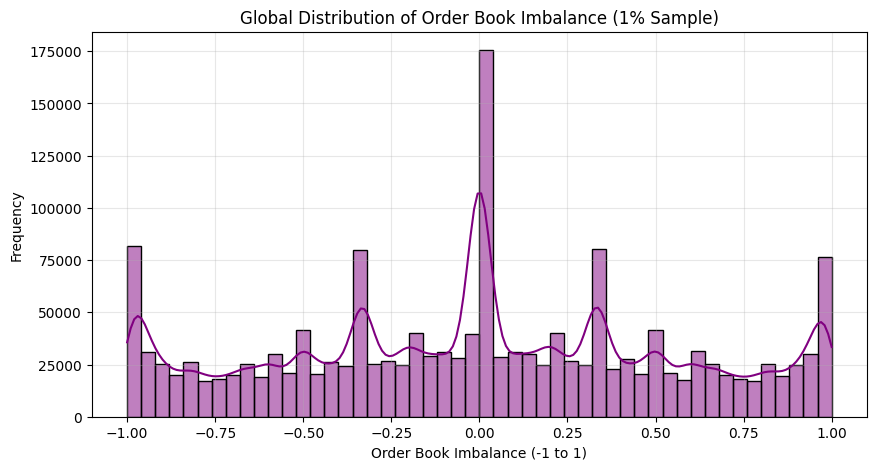

In [ ]:
df_sample = (
    processed_book
    .select(["spread1", "vol_total", "vol_imbalance"])
    .collect()
    .sample(fraction=0.01, seed=42) # Adjust fraction based on your RAM
)

# Plotting the global distribution of the Order Book Imbalance
plt.figure(figsize=(10, 5))
sns.histplot(df_sample['vol_imbalance'].to_numpy(), bins=50, kde=True, color='purple')
plt.title('Global Distribution of Order Book Imbalance (1% Sample)')
plt.xlabel('Order Book Imbalance (-1 to 1)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

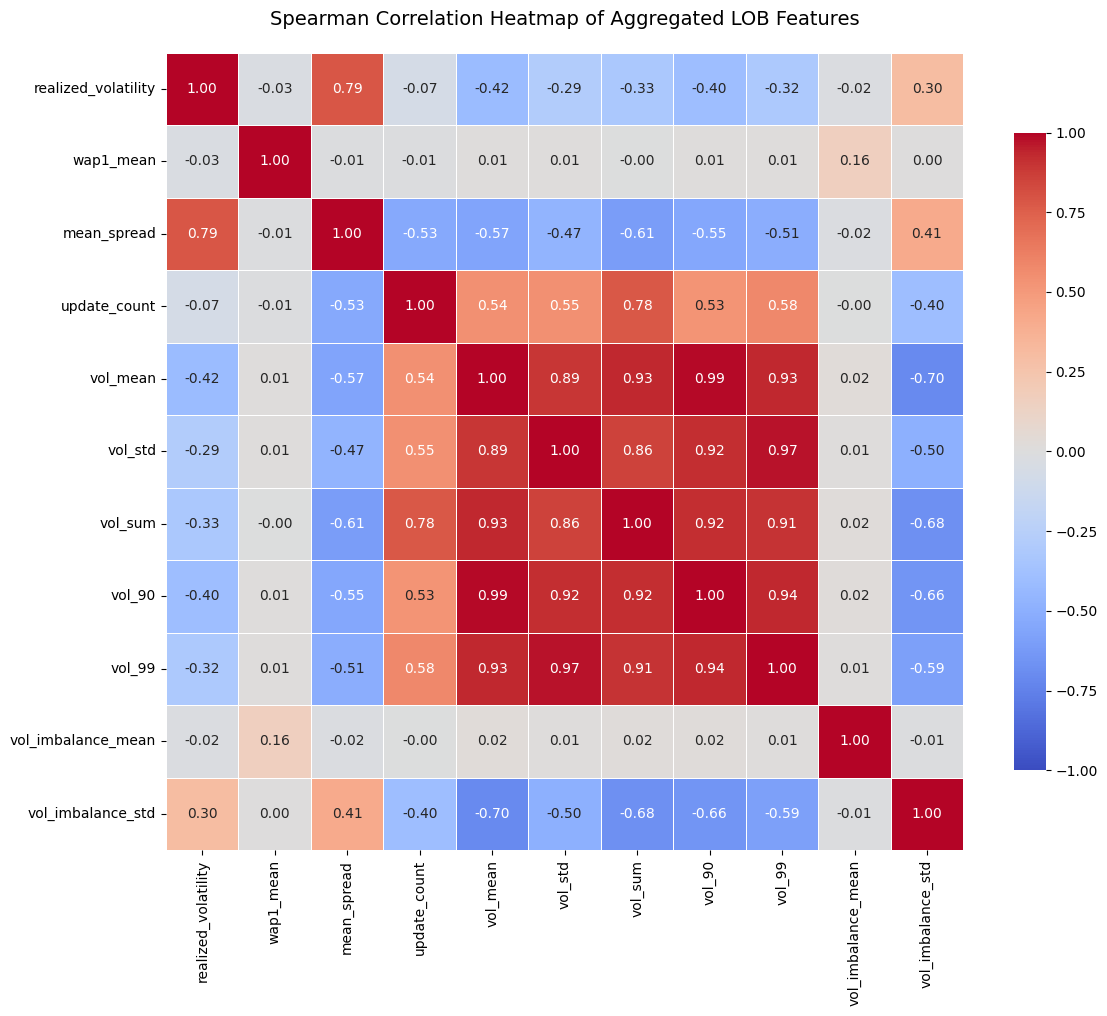

In [ ]:
# Spearman rank correlation Heat map
# Exclude identifiers (we don't want to correlate stock_id or time_id)
df_numeric = aggregated_features.drop(["stock_id", "time_id"])

# Convert to Pandas and calculate the Spearman correlation matrix
# Seaborn natively understands Pandas DataFrames best for index/column labeling
corr_matrix = (df_numeric.collect()).to_pandas().corr(method='spearman')

# Visualize the Heatmap
plt.figure(figsize=(12, 10))

# Create the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,          # Display the correlation coefficients
    fmt=".2f",           # Round to 2 decimal places
    cmap="coolwarm",     # Red for positive correlation, Blue for negative
    vmin=-1, vmax=1,     # Fix the scale from -1 to 1
    center=0,            # Center the colormap at 0
    square=True,         # Make the grid cells square
    linewidths=.5,       # Add lines between cells for readability
    cbar_kws={"shrink": .8} # Shrink the colorbar slightly
)

plt.title("Spearman Correlation Heatmap of Aggregated LOB Features", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

#### Time Series Based Feature Engineering with Polars
Before applying any time-dependent transformations, you must ensure the data is strictly sorted chronologically. If the rows are out of order, your lags and rolling windows will be corrupted.

#### Time-Based Features
Because `seconds_in_bucket` resets to 0 for every `time_id`, it acts as our temporal axis. We can derive features that help a Transformer understand where it is within the 600-second window.

In [ ]:
time_features = processed_book.with_columns(
    # Create 60-second micro-buckets (values 0 through 9)
    # This helps models capture structural behaviors, like end-of-bucket trading spikes
    minute_in_bucket = (pl.col("seconds_in_bucket") // 60).cast(pl.Int8),

    # Calculate the time elapsed since the last order book update
    # We fill the first null value in each bucket with 0
    time_since_last_update = (
        pl.col("seconds_in_bucket")
        - pl.col("seconds_in_bucket").shift(1)
    ).over(["stock_id", "time_id"]).fill_null(0)
)

 #### Lagged Variables
Lagging allows the model to look at the recent past to calculate differentials, such as returns or changes in the bid-ask spread. We use `.shift()` combined with `.over()` to enforce our boundaries.

In [ ]:
lagged_features = (
      time_features.with_columns(
      # Calculate the tick-to-tick Log Return of the Weighted Average Price
      log_return_1t = (
          pl.col("wap1").log() - pl.col("wap1").shift(1).log()
      ).over(["stock_id", "time_id"]),

      # Calculate how much the spread widened or narrowed since the last update
      spread_change = (
          pl.col("spread1") - pl.col("spread1").shift(1)
      ).over(["stock_id", "time_id"])
  ).fill_null(0) # The first return in a bucket is 0
  .with_columns(
        # Calculate squared returns
        log_return_sq=pl.col("log_return") ** 2
    )
    .with_columns(
        # Calculate expanding realized volatility
        realized_volatility=pl.col("log_return_sq").cum_sum().sqrt().over("time_id")
    )
)

#### Moving Window Statistics
Because order book updates arrive irregularly, you have two choices for rolling windows: tick-based (number of rows) or time-based (number of seconds). <br>
Here is how to calculate tick-based rolling statistics using `.rolling_mean()` and `.rolling_std()`. These will calculate metrics over the last $N$ updates, regardless of how much time passed between them.

In [ ]:
rolling_features = lagged_features.with_columns(
    # 10-tick rolling mean of the bid-ask spread
    spread_rolling_mean_10t = (
        pl.col("spread1")
        .rolling_mean(window_size=10)
        .over(["stock_id", "time_id"])
    ),

    # 20-tick rolling standard deviation of log returns (Realized Micro-Volatility)
    # We use a min_periods of 2 so it starts calculating before reaching 20 ticks
    volatility_rolling_20t = (
        pl.col("log_return_1t")
        .rolling_std(window_size=20)
        .over(["stock_id", "time_id"])
    ),

    # Moving sum of order flow imbalance over the last 15 updates
    order_flow_imbalance_15t = (
        (pl.col("bid_size1") - pl.col("ask_size1"))
        .rolling_sum(window_size=15)
        .over(["stock_id", "time_id"])
    )
)

# Collect the lazy frame into memory to see the results
final_engineered_df = rolling_features.collect()

In [ ]:
final_engineered_df

time_id,seconds_in_bucket,bid_price1,ask_price1,bid_price2,ask_price2,bid_size1,ask_size1,bid_size2,ask_size2,stock_id,wap1,spread1,minute_in_bucket,time_since_last_update,log_return_1t,spread_change,spread_rolling_mean_10t,volatility_rolling_20t,order_flow_imbalance_15t
i16,i16,f32,f32,f32,f32,i32,i32,i32,i32,i8,f64,f32,i8,i16,f64,f32,f32,f64,i32
5,0,1.001422,1.002301,1.00137,1.002353,3,226,2,100,0,1.001434,0.000879,0,0,null,null,null,null,null
5,1,1.001422,1.002301,1.00137,1.002353,3,100,2,100,0,1.001448,0.000879,0,1,0.000014,0.0,null,null,null
5,5,1.001422,1.002301,1.00137,1.002405,3,100,2,100,0,1.001448,0.000879,0,4,0.0,0.0,null,null,null
5,6,1.001422,1.002301,1.00137,1.002405,3,126,2,100,0,1.001443,0.000879,0,1,-0.000005,0.0,null,null,null
5,7,1.001422,1.002301,1.00137,1.002405,3,126,2,100,0,1.001443,0.000879,0,1,0.0,0.0,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
32767,588,0.999229,1.000051,0.999177,1.000103,100,200,28,100,126,0.999503,0.000823,9,4,-0.000086,0.000103,0.000509,0.000124,-2534
32767,589,0.999229,1.000051,0.999177,1.000103,100,200,1,100,126,0.999503,0.000823,9,1,0.0,0.0,0.000566,0.000124,-2224
32767,590,0.999229,0.999794,0.999177,1.000051,101,27,1,200,126,0.999675,0.000566,9,1,0.000172,-0.000257,0.000597,0.00013,-1740


In [ ]:
# taking a look at a particular stock
target_stock = 0
target_time_id = 5

df_subset = (
    final_engineered_df
    .filter((pl.col("stock_id") == target_stock) & (pl.col("time_id") == target_time_id))
    .collect()
)

In [ ]:
df_trade = pl.scan_parquet(f'{DATA_DIR}/trade_train.parquet', hive_partitioning=True)

df_trade_adv = (
    df_trade
    .sort(["stock_id", "time_id", "seconds_in_bucket"])
    .with_columns(
        # 1. Inter-Arrival Time (Seconds since the last trade in this bucket)
        inter_arrival_time=pl.col("seconds_in_bucket").diff().over(["stock_id", "time_id"]).fill_null(0),

        # 2. Average Trade Size (Institutional vs. Retail proxy)
        avg_trade_size=(pl.col("size") / pl.col("order_count"))
    )
)

In [ ]:
# loading the whole dataset
# df_book_train_raw = pd.read_parquet(f'{DATA_DIR}/book_train.parquet')
# df_book_test_raw = pd.read_parquet(f'{DATA_DIR}/book_test.parquet')

# df_trade_train_raw = pd.read_parquet(f'{DATA_DIR}/trade_train.parquet')
# df_trade_test_raw = pd.read_parquet(f'{DATA_DIR}/trade_test.parquet')

df_train_raw = pd.read_csv(f'{DATA_DIR}/train.csv')
df_test_raw = pd.read_csv(f'{DATA_DIR}/test.csv')

In [ ]:
# display(df_train_raw.head(5))
# display(df_test_raw.head(5))
display(df_book_train_raw.head(5))
display(df_trade_train_raw.head(5))

In [ ]:
# loading order book data by single stock
df_book_train_stock_id_0 = pd.read_parquet(f'{DATA_DIR}/book_train.parquet/stock_id=0')
display(df_book_train_stock_id_0.head(5))

,time_id,seconds_in_bucket,bid_price1,ask_price1,bid_price2,ask_price2,bid_size1,ask_size1,bid_size2,ask_size2
0,5,0,1.001422,1.002301,1.00137,1.002353,3,226,2,100
1,5,1,1.001422,1.002301,1.00137,1.002353,3,100,2,100
2,5,5,1.001422,1.002301,1.00137,1.002405,3,100,2,100
3,5,6,1.001422,1.002301,1.00137,1.002405,3,126,2,100
4,5,7,1.001422,1.002301,1.00137,1.002405,3,126,2,100


We can start by implementing the EDA functions on a single stock for now

In [ ]:
df_book_train_stock_id_0.isna().sum()

,0
time_id,0
seconds_in_bucket,0
bid_price1,0
ask_price1,0
bid_price2,0
ask_price2,0
bid_size1,0
ask_size1,0
bid_size2,0
ask_size2,0


In [ ]:
df_book_train_stock_id_0['bid_volume'] = df_book_train_stock_id_0[['bid_size1', 'bid_size2']].sum(axis=1)
df_book_train_stock_id_0['ask_volume'] = df_book_train_stock_id_0[['ask_price1', 'ask_price2']].sum(axis=1)
df_book_train_stock_id_0['total_volume'] = df_book_train_stock_id_0['bid_volume'] + df_book_train_stock_id_0['ask_volume']

In [ ]:
df_book_train_stock_id_0[['bid_volume', 'ask_volume', 'total_volume']].describe()

,bid_volume,ask_volume,total_volume
count,917553.000000,917553.000000,917553.000000
mean,200.487343,2.001253,202.488596
std,141.745505,0.007432,141.746100
min,2.000000,1.888793,3.954726
25%,104.000000,1.998619,106.000457
50%,194.000000,2.000829,196.006198
75%,290.000000,2.003301,291.999202
max,4491.000000,2.114027,4493.010052


In [ ]:
df_book_train_stock_id_0.groupby('time_id')['total_volume'].describe()

,count,mean,std,min,25%,50%,75%,max
time_id,,,,,,,,
5,302.0,161.154184,112.361280,4.006309,103.008895,136.008791,206.259464,642.008533
11,200.0,247.410946,117.043046,17.000904,203.000891,260.001204,326.750452,510.000703
16,188.0,212.659630,109.302608,8.996075,131.001723,202.001005,289.751137,458.000431
31,120.0,185.240384,95.675036,25.999028,126.999028,155.998612,248.997502,451.998011
62,176.0,209.664490,96.643145,3.999487,107.000455,203.999814,293.000035,437.999907
...,...,...,...,...,...,...,...,...
32751,297.0,174.414071,147.915823,4.994277,21.997347,131.996826,310.997763,542.997659
32753,206.0,272.448141,194.481026,4.002503,106.000113,283.501977,402.002803,970.002203
32758,188.0,140.249800,87.317906,5.999143,104.001310,120.000932,201.998224,526.999345
